DATA ANALYSIS

SECTION 1 - EXPLORATION AND PREPROCESSING OF THE DATASET

In [1]:
import os
import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    GITHUB_USER = "SinghSahiljit44"  # Es. sahiljit
    REPO_NAME = "Weather_forecasting"
    REPO_URL = f"https://github.com/{GITHUB_USER}/{REPO_NAME}.git"

    # Clona la repository se non è già stata clonata nella sessione
    if not os.path.exists(REPO_NAME):
        !git clone {REPO_URL}

    # Cambia la directory di lavoro nella root del progetto
    os.chdir(REPO_NAME)
    
    # Installa le dipendenze necessarie nell'ambiente di Colab
    !pip install -q -r requirements.txt
    
    PROJECT_ROOT = Path.cwd()
else:
    # --- CONFIGURAZIONE LOCALE  ---
    PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
    os.chdir(PROJECT_ROOT)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print(f" [OK] Ambiente rilevato: {'Google Colab' if IN_COLAB else 'Locale'}")
print(f" [OK] Directory di lavoro impostata a: {Path.cwd()}")

 [OK] Ambiente rilevato: Locale
 [OK] Directory di lavoro impostata a: c:\Users\sahil\GitHub\Weather_forecasting


In [8]:
from src.data.dataset import load_hourly

# Carica il dataframe con i dati orari
df_hourly = load_hourly()

# Mostra le prime 48 ore (i primi due giorni completi)
df_hourly.head(48)

,t2m,skt,stl1,stl2,stl3,stl4,swvl1,swvl2,swvl3,swvl4,pev,e,tp
time,,,,,,,,,,,,,
1990-01-01 00:00:00,3.691919,2.302026,4.594263,6.877100,10.465723,16.038232,0.435532,0.417847,0.331802,0.314011,-0.877649,-0.366595,0.556895
1990-01-01 01:00:00,3.363550,1.943262,4.407495,6.798730,10.456079,16.034937,0.435349,0.417847,0.331833,0.314011,0.002131,0.002133,0.005156
1990-01-01 02:00:00,2.892114,1.389429,4.137476,6.712305,10.446436,16.031641,0.435135,0.417862,0.331848,0.314011,0.004981,0.004981,0.005418
1990-01-01 03:00:00,3.162744,1.776025,4.190332,6.631738,10.436792,16.028345,0.434967,0.417862,0.331863,0.314011,0.007249,0.007248,0.007827
1990-01-01 04:00:00,3.888330,2.631738,4.450952,6.572656,10.428979,16.025049,0.435364,0.417877,0.331879,0.314011,0.008661,0.008662,0.062440
1990-01-01 05:00:00,4.498682,3.321436,4.708276,6.531396,10.419092,16.021753,0.437424,0.417892,0.331894,0.314011,0.009891,0.009893,0.238009
1990-01-01 06:00:00,5.317163,4.297266,5.101099,6.513818,10.409204,16.016626,0.440689,0.417938,0.331909,0.314011,0.008993,0.008994,0.492454
1990-01-01 07:00:00,5.892480,4.971582,5.426172,6.513818,10.399194,16.013330,0.442307,0.417984,0.331940,0.314011,0.007238,0.007237,0.633188
1990-01-01 08:00:00,6.500513,5.696436,5.792871,6.535913,10.389185,16.010034,0.443939,0.418060,0.331955,0.314011,0.003539,0.003539,0.779666


In [ ]:
# No missing values 
df_hourly.isnull().sum()

t2m      0
skt      0
stl1     0
stl2     0
stl3     0
stl4     0
swvl1    0
swvl2    0
swvl3    0
swvl4    0
pev      0
e        0
tp       0
dtype: int64

In [4]:
from src.data.preprocessing import load_daily

# Carica il dataframe con i dati giornalieri
df_daily = load_daily()

# Mostra ultimi 2 giorni
df_daily.tail(2)

,t2m_mean,t2m_min,t2m_max,tp_mm,e_mm,pev_mm,skt_mean,stl1_mean,stl2_mean,stl3_mean,stl4_mean,swvl1_mean,swvl2_mean,swvl3_mean,swvl4_mean
date,,,,,,,,,,,,,,,
2025-12-29,7.517165,2.175928,13.133081,0.000852,-0.609646,-1.373537,5.763895,7.700311,9.291325,12.367039,18.182240,0.423934,0.419802,0.381882,0.304296
2025-12-30,6.777755,1.362451,12.849390,0.776327,-0.636903,-1.522161,5.722381,6.934641,8.187143,12.166803,18.094665,0.421186,0.418313,0.381873,0.304318


### ERA5-Land Dataset Variables Summary

| Variable Code | Long Name | Unit (in dataset) | Processing Type | Description |
|---|---|---|---|---|
| **t2m** | 2 metre temperature | °C | Instantaneous | Temperature of air at 2 m above the surface. |
| **skt** | Skin temperature | °C | Instantaneous | Temperature of the surface of the Earth. |
| **stl1** | Soil temperature level 1 | °C | Instantaneous | Temperature of soil in layer 1 (0 – 7 cm). |
| **stl2** | Soil temperature level 2 | °C | Instantaneous | Temperature of soil in layer 2 (7 – 28 cm). |
| **stl3** | Soil temperature level 3 | °C | Instantaneous | Temperature of soil in layer 3 (28 – 100 cm). |
| **stl4** | Soil temperature level 4 | °C | Instantaneous | Temperature of soil in layer 4 (100 – 289 cm). |
| **swvl1** | Volumetric soil water layer 1 | m³/m³ | Instantaneous | Volume fraction of water in soil layer 1 (0 – 7 cm). |
| **swvl2** | Volumetric soil water layer 2 | m³/m³ | Instantaneous | Volume fraction of water in soil layer 2 (7 – 28 cm). |
| **swvl3** | Volumetric soil water layer 3 | m³/m³ | Instantaneous | Volume fraction of water in soil layer 3 (28 – 100 cm). |
| **swvl4** | Volumetric soil water layer 4 | m³/m³ | Instantaneous | Volume fraction of water in soil layer 4 (100 – 289 cm). |
| **pev** | Potential evaporation | mm | Accumulated | Evaporation if water supply were unlimited. |
| **e** | Total evaporation | mm | Accumulated | Accumulated evaporation from Earth's surface. |
| **tp** | Total precipitation | mm | Accumulated | Accumulated precipitation. |

*Note: `lai_hv` and `lai_lv` are dropped during dataset loading (`dataset.py`). All temperatures are pre-converted from Kelvin to °C, and accumulated fields from meters to mm.*

SECTION 2 - STATIONARITY ANALYSIS 

SUBSECTION 2.1 - STATIONARITY OF TEMPERATURE 

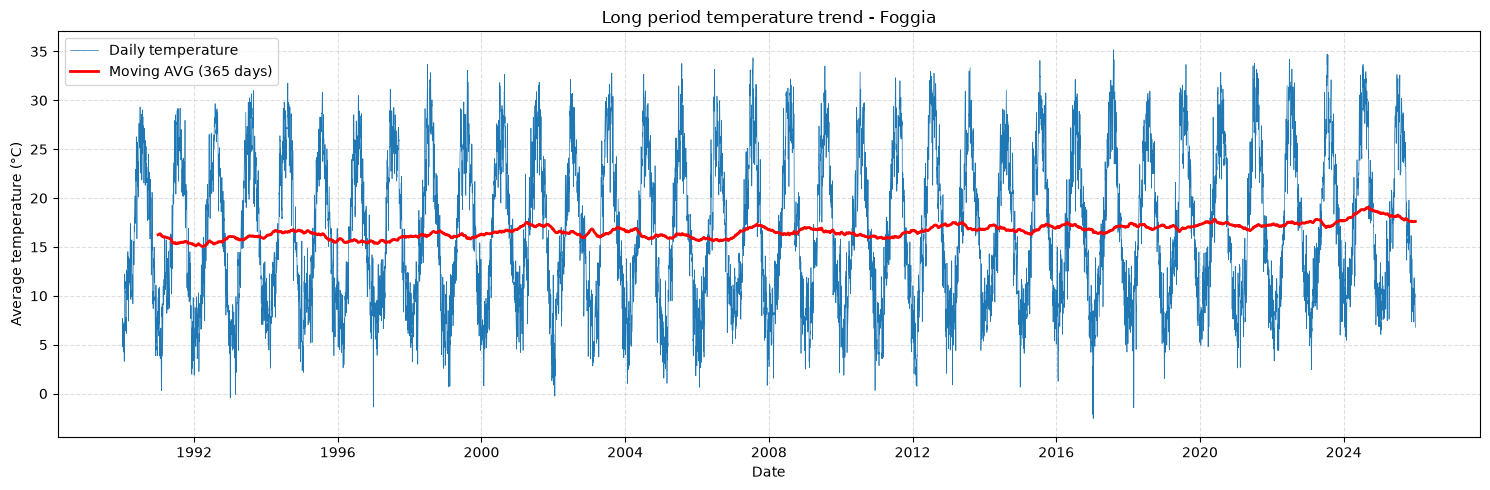

Missing values: 0
count    13148.000000
mean        16.643189
std          7.717068
min         -2.550818
25%         10.092841
50%         15.891674
75%         23.105884
max         35.174905
Name: t2m_mean, dtype: float64


In [24]:
#TIME SERIES TREND 

import matplotlib.pyplot as plt
import pandas as pd
from src.data.preprocessing import load_daily

df_daily = load_daily()

series = df_daily["t2m_mean"].sort_index()

rolling_mean = series.rolling(
    window=365,
    min_periods=365
).mean()

plt.figure(figsize=(15, 5))

plt.plot(
    series.index,
    series.values,
    color="tab:blue",
    linewidth=0.5,
    label="Daily temperature"
)

plt.plot(
    rolling_mean.index,
    rolling_mean.values,
    color="red",
    linewidth=2,
    label="Moving AVG (365 days)"
)

plt.title("Long period temperature trend - Foggia")
plt.xlabel("Date")
plt.ylabel("Average temperature (°C)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

# Verifica dei valori mancanti e statistiche descrittive
print("Missing values:", series.isna().sum())
print(series.describe())


COMMENT: Using a moving average we can observe that the temperatures are rising

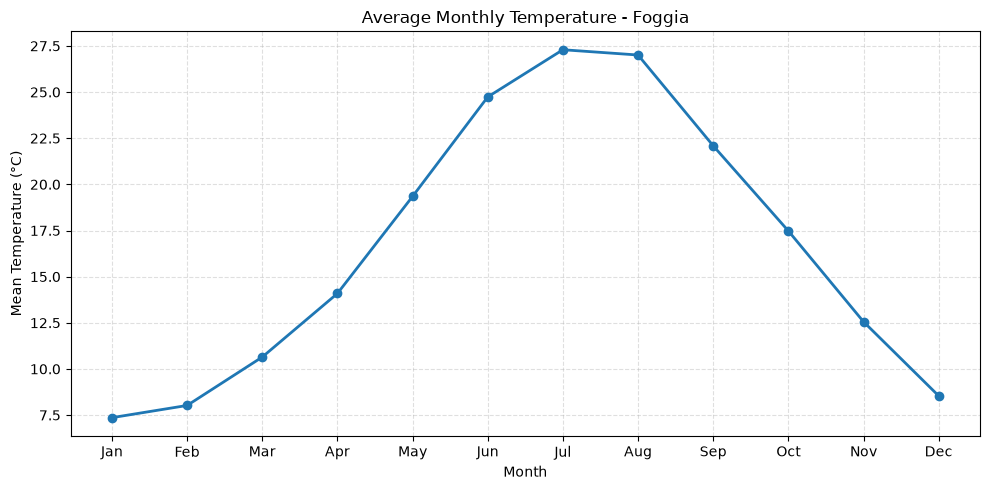

In [ ]:
#Seasonality

monthly_mean = series.groupby(series.index.month).mean()

month_labels = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

plt.figure(figsize=(10, 5))

plt.plot(
    monthly_mean.index,
    monthly_mean.values,
    marker="o",
    linewidth=2
)

plt.xticks(range(1, 13), month_labels)
plt.title("Average Monthly Temperature - Foggia")
plt.xlabel("Month")
plt.ylabel("Mean Temperature (°C)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

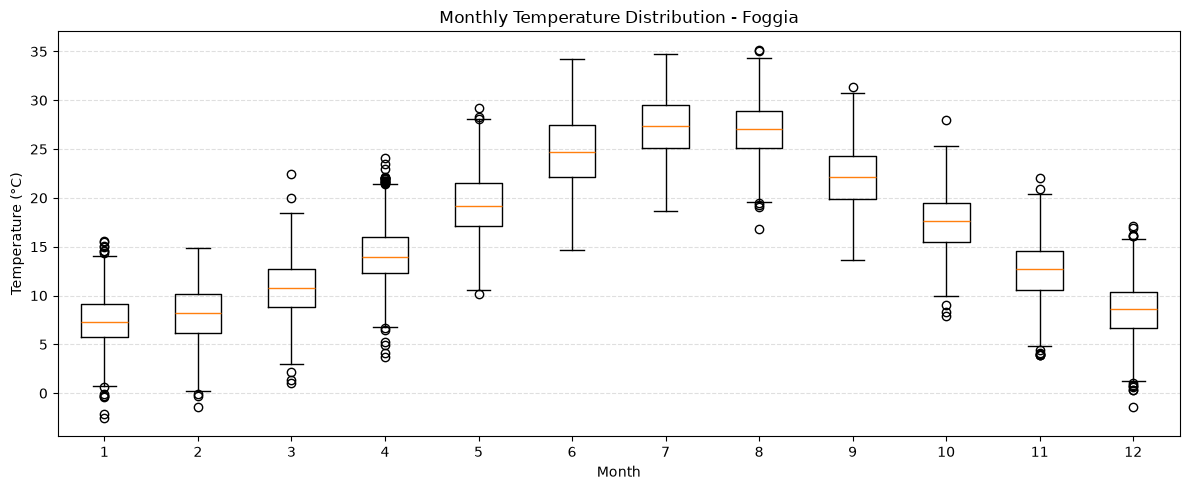

In [ ]:
#Seasonality box-plot

df_plot = pd.DataFrame({
    "month": series.index.month,
    "temperature": series.values
})

data_by_month = [
    df_plot.loc[
        df_plot["month"] == month,
        "temperature"
    ]
    for month in range(1, 13)
]

plt.figure(figsize=(12, 5))

plt.boxplot(data_by_month, label=month_labels)

plt.title("Monthly Temperature Distribution - Foggia")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.grid(True, axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

COMMENT: Typical seasonal pattern of the mediterranean

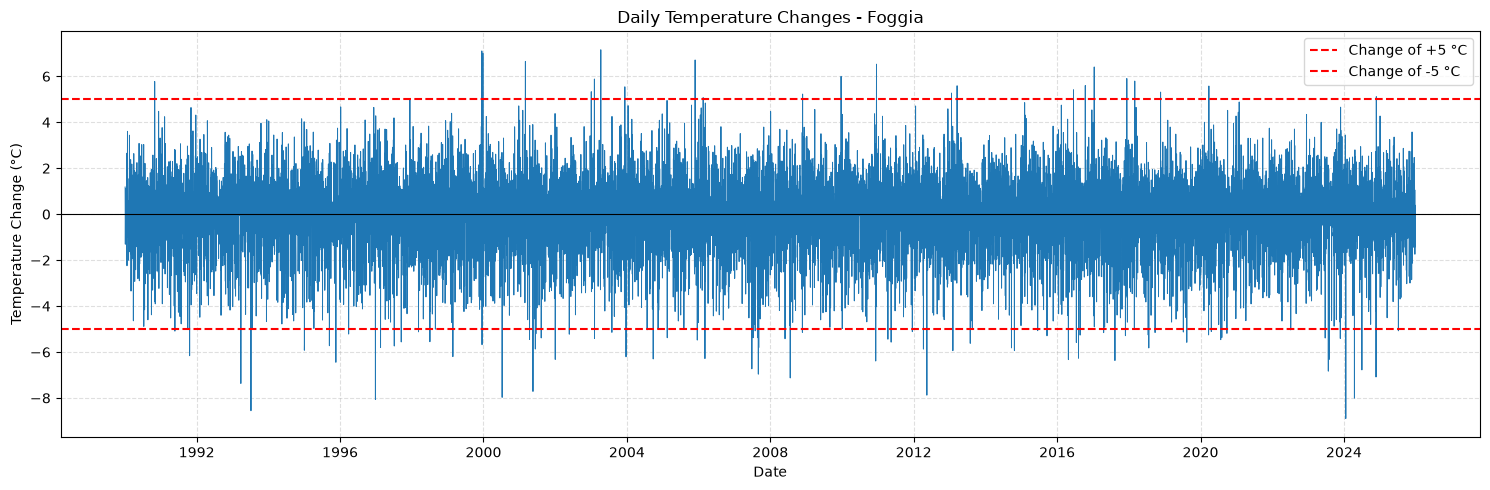

Daily changes exceeding 5 °C:
date
1990-10-30    5.775691
1991-05-24   -5.089060
1991-10-21   -6.159368
1993-03-26   -7.367940
1993-07-07   -8.553828
                ...   
2024-04-17   -8.006226
2024-07-02   -6.777990
2024-11-23   -7.086568
2024-11-26    5.115130
2025-07-09   -5.075607
Name: t2m_mean, Length: 109, dtype: float64


In [28]:
daily_change = series.diff()

plt.figure(figsize=(15, 5))

plt.plot(
    daily_change.index,
    daily_change.values,
    linewidth=0.7
)

plt.axhline(0, color="black", linewidth=0.8)
plt.axhline(
    5, color="red", linestyle="--",
    label="Change of +5 °C"
)
plt.axhline(
    -5, color="red", linestyle="--",
    label="Change of -5 °C"
)

plt.title("Daily Temperature Changes - Foggia")
plt.xlabel("Date")
plt.ylabel("Temperature Change (°C)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

# Identify large day-to-day changes
sudden_changes = daily_change[daily_change.abs() > 5]

print("Daily changes exceeding 5 °C:")
print(sudden_changes)

COMMENT: a -8 degrees variation in 2024 => BURIAN wind

In [31]:
#STL DECOMPOSITION
import matplotlib.pyplot as plt
import pandas as pd
from statsmodels.tsa.seasonal import STL

from src.data.preprocessing import load_daily

# Load daily weather data
df_daily = load_daily()

# Extract the daily mean temperature series
series = df_daily["t2m_mean"].copy()
series.index = pd.to_datetime(series.index)
series = series.sort_index()

# Ensure a regular daily frequency
series = series.asfreq("D")

# Check missing values
print("Missing values:", series.isna().sum())

# Interpolate missing values for the STL decomposition
# Only do this if the number of missing values is limited.
series_stl = series.interpolate(method="time", limit_area="inside")

# Check whether any missing values remain
if series_stl.isna().any():
    raise ValueError(
        "The series still contains missing values. "
        "Handle missing observations before applying STL."
    )

# Apply STL decomposition
# Period = 365 days for yearly seasonality in daily data
stl = STL(
    series_stl,
    period=365,
    robust=True
)

result = stl.fit()

# Plot the decomposition
fig = result.plot()
fig.set_size_inches(14, 10)
fig.suptitle(
    "STL Decomposition of Daily Mean Temperature - Foggia",
    fontsize=14,
    y=1.02
)
plt.tight_layout()
plt.show()

# Plot each component separately if needed
fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

axes[0].plot(series_stl.index, series_stl, color="tab:blue")
axes[0].set_title("Observed")
axes[1].plot(result.trend.index, result.trend, color="tab:orange")
axes[1].set_title("Trend")
axes[2].plot(result.seasonal.index, result.seasonal, color="tab:green")
axes[2].set_title("Seasonal")
axes[3].plot(result.resid.index, result.resid, color="tab:red")
axes[3].set_title("Residual")

for ax in axes:
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.set_ylabel("Temperature (°C)")

axes[-1].set_xlabel("Date")

plt.tight_layout()
plt.show()

ImportError: DLL load failed while importing levyst: Un criterio di controllo dell'applicazione ha bloccato il file.

SUBSECTION 2.2 - STATIONARITY OF PRECIPITATIONS 